# Tornado Time Evolution

Reframing the radar-placement question around how tornado activity has
shifted over time and space, rather than casualty/lead-time prediction.

Core features: `BEGIN_LAT`, `BEGIN_LON`, `month`, `ef_scale`.


In [1]:
import gzip, glob, json
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import FuncFormatter
from scipy.stats import theilslopes
from sklearn.linear_model import QuantileRegressor

# US longitudes are negative (East-positive convention); display them as
# positive degrees West on plot axes without flipping the underlying data
# or map orientation.
lon_west_formatter = FuncFormatter(lambda x, _: f"{abs(x):.0f}°W")


## Load Tornado Event Data


In [2]:
RAW = "../data/raw"

KEEP_COLS = [
    "EVENT_ID",
    "BEGIN_YEARMONTH",
    "TOR_F_SCALE",
    "BEGIN_LAT",
    "BEGIN_LON",
]

frames = []

for path in sorted(glob.glob(RAW + "/StormEvents_details-ftp_v1.0_d*.csv.gz")):
    with gzip.open(path, "rt", encoding="latin-1") as f:
        df_year = pd.read_csv(f, low_memory=False)
    df_year = df_year[df_year["EVENT_TYPE"].str.upper() == "TORNADO"].copy()
    df_year = df_year[[c for c in KEEP_COLS if c in df_year.columns]]
    df_year["year"] = path.split("_")[-2].split("d")[1]
    frames.append(df_year)

df = pd.concat(frames, ignore_index=True)
df["year"] = df["year"].astype(int)
df["month"] = df["BEGIN_YEARMONTH"] % 100

print(f"Tornado events loaded : {len(df):,}")
print(f"Year range            : {df['year'].min()}-{df['year'].max()}")
print(f"Columns               : {list(df.columns)}")
df.head()


Tornado events loaded : 49,437
Year range            : 1990-2025
Columns               : ['EVENT_ID', 'BEGIN_YEARMONTH', 'TOR_F_SCALE', 'BEGIN_LAT', 'BEGIN_LON', 'year', 'month']


,EVENT_ID,BEGIN_YEARMONTH,TOR_F_SCALE,BEGIN_LAT,BEGIN_LON,year,month
0,10049091,199006,F1,44.37,-92.63,1990,6
1,10041359,199005,F0,42.08,-71.40,1990,5
2,10079985,199006,F0,41.10,-98.47,1990,6
3,10079988,199006,F0,41.52,-97.73,1990,6
4,10080010,199006,F4,40.25,-100.75,1990,6


## Parse EF / F Scale to Numeric (0-5)

`TOR_F_SCALE` holds strings like `EF0`-`EF5` (post-2007) or `F0`-`F5`
(pre-2007). Both scales map 1:1 onto a 0-5 numeric intensity — extract
the digit directly.


In [3]:
df["ef_scale"] = pd.to_numeric(
    df["TOR_F_SCALE"].str.extract(r"(\d+)")[0], errors="coerce"
).astype("Int64")

print("EF/F scale value counts:")
print(df["ef_scale"].value_counts().sort_index())
print(f"\nMissing / unknown (EFU etc.) : {df['ef_scale'].isna().sum():,}")
df[["TOR_F_SCALE", "ef_scale"]].drop_duplicates().sort_values("ef_scale")


EF/F scale value counts:
ef_scale
0    25815
1    15591
2     4584
3     1371
4      330
5       34
Name: count, dtype: Int64

Missing / unknown (EFU etc.) : 1,712


,TOR_F_SCALE,ef_scale
1,F0,0
21779,EF0,0
0,F1,1
21781,EF1,1
45,F2,2
21780,EF2,2
34,F3,3
21951,EF3,3
4,F4,4
22161,EF4,4


## Clean & Filter to CONUS


In [4]:
FEATURES = ["BEGIN_LAT", "BEGIN_LON", "month", "ef_scale"]

df_model = df.dropna(subset=FEATURES).copy()
df_model["ef_scale"] = df_model["ef_scale"].astype(int)

# CONUS bounding box
df_model = df_model[
    (df_model["BEGIN_LON"] >= -130) & (df_model["BEGIN_LON"] <= -60) &
    (df_model["BEGIN_LAT"] >=   20) & (df_model["BEGIN_LAT"] <=   55)
].copy()

print(f"Events with complete features : {len(df_model):,}")
print(f"Year range                    : {df_model['year'].min()}-{df_model['year'].max()}")
df_model[FEATURES + ["year"]].describe()


Events with complete features : 46,569
Year range                    : 1990-2025


,BEGIN_LAT,BEGIN_LON,month,ef_scale,year
count,46569.000000,46569.000000,46569.000000,46569.000000,46569.000000
mean,37.132047,-92.014672,5.877945,0.638279,2008.264790
std,4.872245,8.252694,2.613537,0.832443,10.098788
min,24.544000,-124.468200,1.000000,0.000000,1990.000000
25%,33.293800,-97.565000,4.000000,0.000000,2000.000000
50%,36.944700,-92.156200,5.000000,0.000000,2008.000000
75%,40.719700,-86.415300,7.000000,1.000000,2017.000000
max,49.330000,-67.807000,12.000000,5.000000,2025.000000


## Exploratory Data Analysis

Spatial and temporal trends before any modeling.


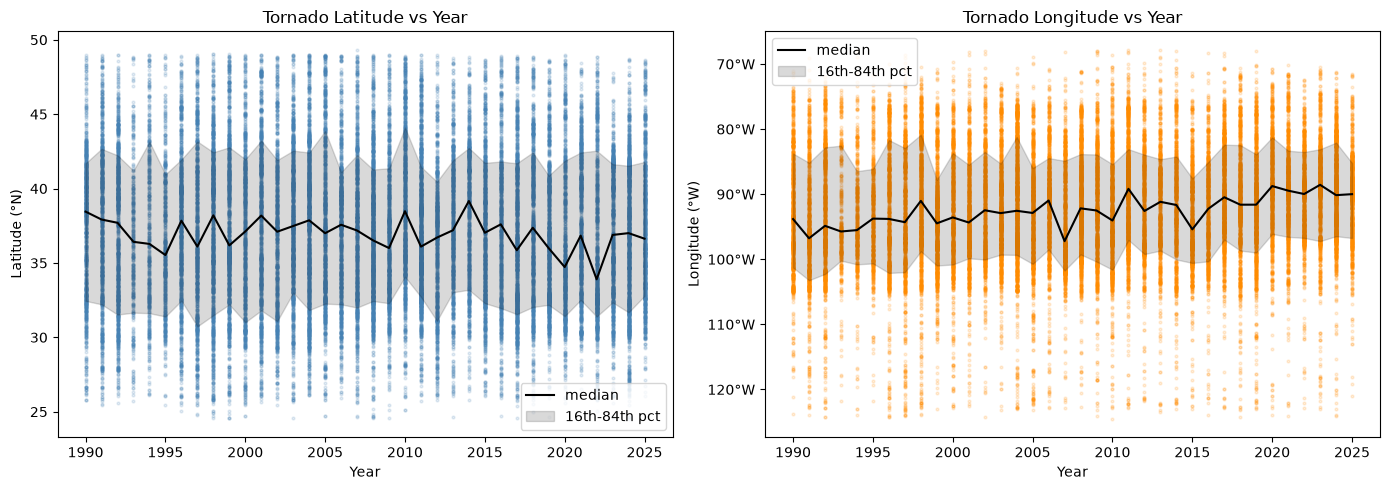

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df_model["year"], df_model["BEGIN_LAT"], s=4, alpha=0.15, color="steelblue")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Latitude (°N)")
axes[0].set_title("Tornado Latitude vs Year")

axes[1].scatter(df_model["year"], df_model["BEGIN_LON"], s=4, alpha=0.15, color="darkorange")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Longitude (°W)")
axes[1].yaxis.set_major_formatter(lon_west_formatter)
axes[1].set_title("Tornado Longitude vs Year")

# Overlay yearly median + shaded 16th-84th percentile band (robust to outliers)
lat_q = df_model.groupby("year")["BEGIN_LAT"].quantile([0.16, 0.50, 0.84]).unstack()
lon_q = df_model.groupby("year")["BEGIN_LON"].quantile([0.16, 0.50, 0.84]).unstack()

axes[0].plot(lat_q.index, lat_q[0.50], color="black", lw=1.5, label="median")
axes[0].fill_between(lat_q.index, lat_q[0.16], lat_q[0.84], color="black", alpha=0.15, label="16th-84th pct")
axes[1].plot(lon_q.index, lon_q[0.50], color="black", lw=1.5, label="median")
axes[1].fill_between(lon_q.index, lon_q[0.16], lon_q[0.84], color="black", alpha=0.15, label="16th-84th pct")
axes[0].legend()
axes[1].legend()

plt.tight_layout()
plt.show()


In [6]:
# Quantify the trend with a Theil-Sen slope (median of pairwise slopes —
# robust to outliers, consistent with the percentile-band approach above).
# Fit on yearly medians (not raw events): Theil-Sen is O(n^2) in pairwise
# slopes, and yearly medians are already outlier-robust + far fewer points.

lat_slope, lat_intercept, lat_lo, lat_hi = theilslopes(lat_q[0.50].values, lat_q.index.values)
lon_slope, lon_intercept, lon_lo, lon_hi = theilslopes(lon_q[0.50].values, lon_q.index.values)

# Convert degrees/year to km/decade for interpretability
km_per_deg_lat = 111.0
km_per_deg_lon = 111.0 * np.cos(np.deg2rad(df_model["BEGIN_LAT"].mean()))

print("Theil-Sen trend on yearly medians (per year), 95% CI on slope:")
print(f"  Latitude  : {lat_slope:+.4f}°/yr  [{lat_lo:+.4f}, {lat_hi:+.4f}]  "
      f"→ {lat_slope*10*km_per_deg_lat:+.1f} km/decade")
print(f"  Longitude : {lon_slope:+.4f}°/yr  [{lon_lo:+.4f}, {lon_hi:+.4f}]  "
      f"→ {lon_slope*10*km_per_deg_lon:+.1f} km/decade (+ = eastward)")

print("\nSlope is significant if the CI excludes 0.")
print(f"  Latitude  CI excludes 0 : {lat_lo > 0 or lat_hi < 0}")
print(f"  Longitude CI excludes 0 : {lon_lo > 0 or lon_hi < 0}")


Theil-Sen trend on yearly medians (per year), 95% CI on slope:
  Latitude  : -0.0303°/yr  [-0.0600, +0.0027]  → -33.6 km/decade
  Longitude : +0.1584°/yr  [+0.1179, +0.2009]  → +140.2 km/decade (+ = eastward)

Slope is significant if the CI excludes 0.
  Latitude  CI excludes 0 : False
  Longitude CI excludes 0 : True


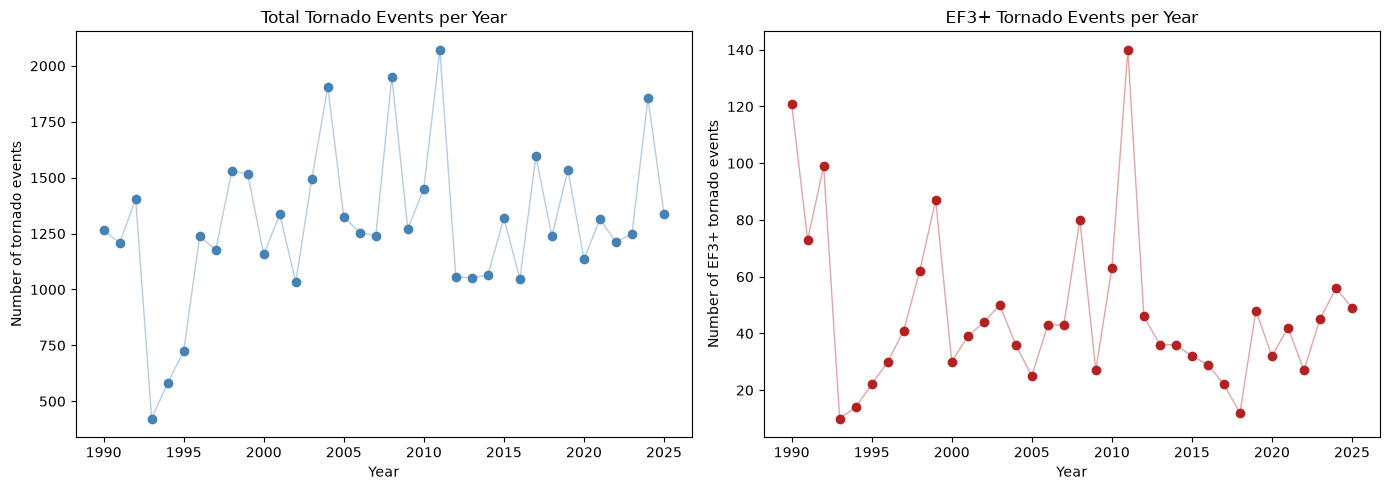

In [7]:
counts_by_year = df_model.groupby("year").size()
ef3plus_by_year = df_model[df_model["ef_scale"] >= 3].groupby("year").size()
# Reindex so years with zero EF3+ events still show as 0, not missing
ef3plus_by_year = ef3plus_by_year.reindex(counts_by_year.index, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(counts_by_year.index, counts_by_year.values, color="steelblue")
axes[0].plot(counts_by_year.index, counts_by_year.values, color="steelblue", alpha=0.4, lw=1)
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Number of tornado events")
axes[0].set_title("Total Tornado Events per Year")

axes[1].scatter(ef3plus_by_year.index, ef3plus_by_year.values, color="firebrick")
axes[1].plot(ef3plus_by_year.index, ef3plus_by_year.values, color="firebrick", alpha=0.4, lw=1)
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Number of EF3+ tornado events")
axes[1].set_title("EF3+ Tornado Events per Year")

plt.tight_layout()
plt.show()


In [8]:
# Quantify the trend in total tornado events per year with a Theil-Sen
# slope (robust to outlier years, e.g. unusually active/quiet seasons).
counts_slope, counts_intercept, counts_lo, counts_hi = theilslopes(
    counts_by_year.values, counts_by_year.index.values
)

print("Theil-Sen trend, total tornado events per year, 95% CI on slope:")
print(f"  {counts_slope:+.2f} events/yr  [{counts_lo:+.2f}, {counts_hi:+.2f}]  "
      f"→ {counts_slope*10:+.1f} events/decade")
print(f"  CI excludes 0 (significant) : {counts_lo > 0 or counts_hi < 0}")


Theil-Sen trend, total tornado events per year, 95% CI on slope:
  +4.38 events/yr  [-3.70, +18.04]  → +43.8 events/decade
  CI excludes 0 (significant) : False


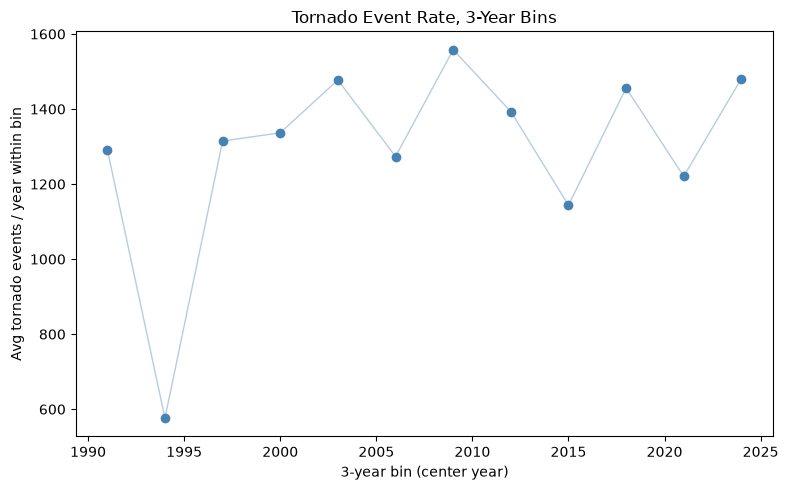

Theil-Sen trend, 3-year-binned tornado event rate, 95% CI on slope:
  +5.87 events/yr  [-5.13, +20.00]  → +58.7 events/decade
  CI excludes 0 (significant) : False

For comparison, annual series : +4.38 events/yr  [-3.70, +18.04]  (significant: False)


In [9]:
# Bin years into 3-year windows (same width used in the forecasting section)
# and check whether smoothing away single-year noise reveals a trend the
# annual series didn't have enough power to detect. Report the average
# annual rate within each bin (not the raw bin total) so the slope stays
# in events/yr, directly comparable to the annual-series result above.
BIN_WIDTH_EDA = 3
year_min = df_model["year"].min()
bin_start = year_min + ((df_model["year"] - year_min) // BIN_WIDTH_EDA) * BIN_WIDTH_EDA

counts_by_bin = df_model.groupby(bin_start).size()
bin_centers = counts_by_bin.index.values + (BIN_WIDTH_EDA - 1) / 2
counts_annualized = counts_by_bin.values / BIN_WIDTH_EDA  # avg events/year within each bin

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(bin_centers, counts_annualized, color="steelblue")
ax.plot(bin_centers, counts_annualized, color="steelblue", alpha=0.4, lw=1)
ax.set_xlabel("3-year bin (center year)")
ax.set_ylabel("Avg tornado events / year within bin")
ax.set_title("Tornado Event Rate, 3-Year Bins")
plt.tight_layout()
plt.show()

bin_slope, bin_intercept, bin_lo, bin_hi = theilslopes(counts_annualized, bin_centers)

print("Theil-Sen trend, 3-year-binned tornado event rate, 95% CI on slope:")
print(f"  {bin_slope:+.2f} events/yr  [{bin_lo:+.2f}, {bin_hi:+.2f}]  → {bin_slope*10:+.1f} events/decade")
print(f"  CI excludes 0 (significant) : {bin_lo > 0 or bin_hi < 0}")
print(f"\nFor comparison, annual series : {counts_slope:+.2f} events/yr  "
      f"[{counts_lo:+.2f}, {counts_hi:+.2f}]  "
      f"(significant: {counts_lo > 0 or counts_hi < 0})")


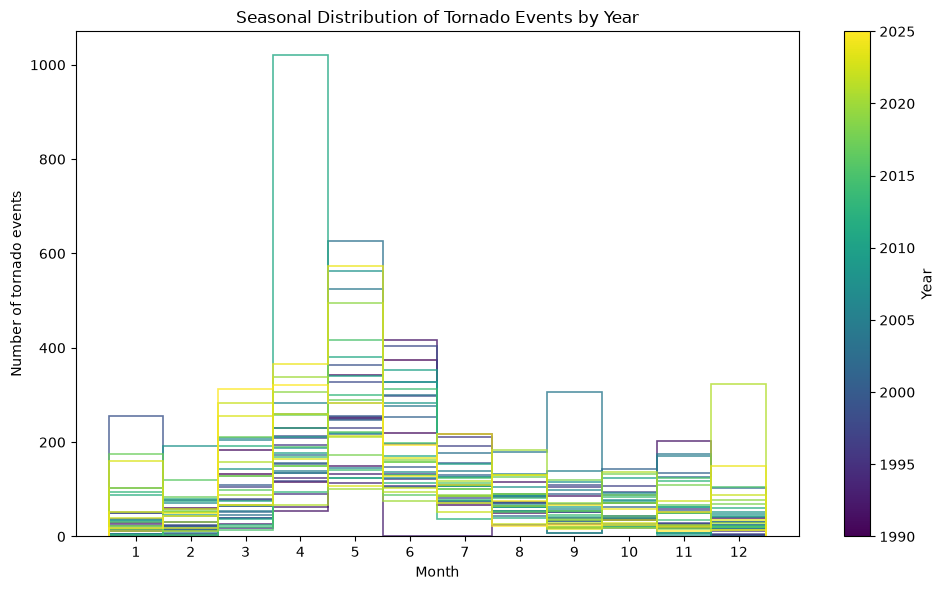

In [10]:
# Unfilled (step) histogram of events-by-month, one line per year,
# colored by year using a sequential colormap.
years = sorted(df_model["year"].unique())
cmap = plt.cm.viridis
norm = mcolors.Normalize(vmin=min(years), vmax=max(years))

fig, ax = plt.subplots(figsize=(10, 6))

bins = np.arange(0.5, 13.5, 1)  # 12 bins centered on months 1-12

for yr in years:
    month_vals = df_model.loc[df_model["year"] == yr, "month"]
    ax.hist(
        month_vals, bins=bins, histtype="step",
        color=cmap(norm(yr)), linewidth=1.2, alpha=0.8,
    )

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("Year")

ax.set_xticks(range(1, 13))
ax.set_xlabel("Month")
ax.set_ylabel("Number of tornado events")
ax.set_title("Seasonal Distribution of Tornado Events by Year")

plt.tight_layout()
plt.show()


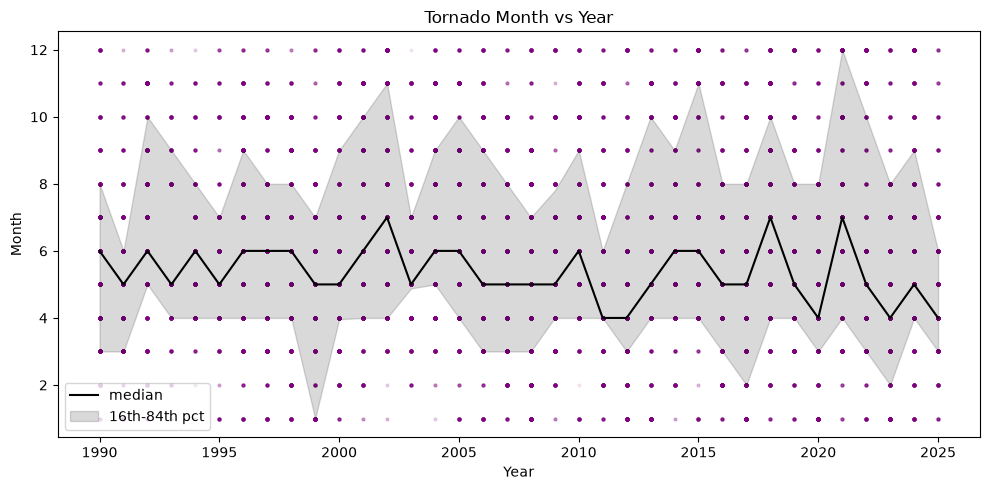

Theil-Sen trend, median tornado month per year, 95% CI on slope:
  -0.00000 months/yr  [-0.04348, -0.00000]  → -0.000 months/decade
  CI excludes 0 (significant) : False


In [11]:
# Quantify whether the timing of tornado season is shifting: median month
# per year (robust to outlier events) with a 16th-84th percentile band,
# same approach used for the lat/lon trend above.
month_q = df_model.groupby("year")["month"].quantile([0.16, 0.50, 0.84]).unstack()

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(df_model["year"], df_model["month"], s=4, alpha=0.08, color="purple")
ax.plot(month_q.index, month_q[0.50], color="black", lw=1.5, label="median")
ax.fill_between(month_q.index, month_q[0.16], month_q[0.84], color="black", alpha=0.15, label="16th-84th pct")
ax.set_xlabel("Year")
ax.set_ylabel("Month")
ax.set_title("Tornado Month vs Year")
ax.legend()
plt.tight_layout()
plt.show()

month_slope, month_intercept, month_lo, month_hi = theilslopes(month_q[0.50].values, month_q.index.values)

print("Theil-Sen trend, median tornado month per year, 95% CI on slope:")
print(f"  {month_slope:+.5f} months/yr  [{month_lo:+.5f}, {month_hi:+.5f}]  "
      f"→ {month_slope*10:+.3f} months/decade")
print(f"  CI excludes 0 (significant) : {month_lo > 0 or month_hi < 0}")


## Spatial Shift: Early vs Recent Period

Compare tornado density maps for the first decade (1990-1999) against the
most recent decade, to visualize the eastward shift quantified above.
Both periods span exactly 10 years so raw counts are directly comparable.


Early period  1990-1999 : 11,066 events
Recent period 2016-2025 : 13,521 events


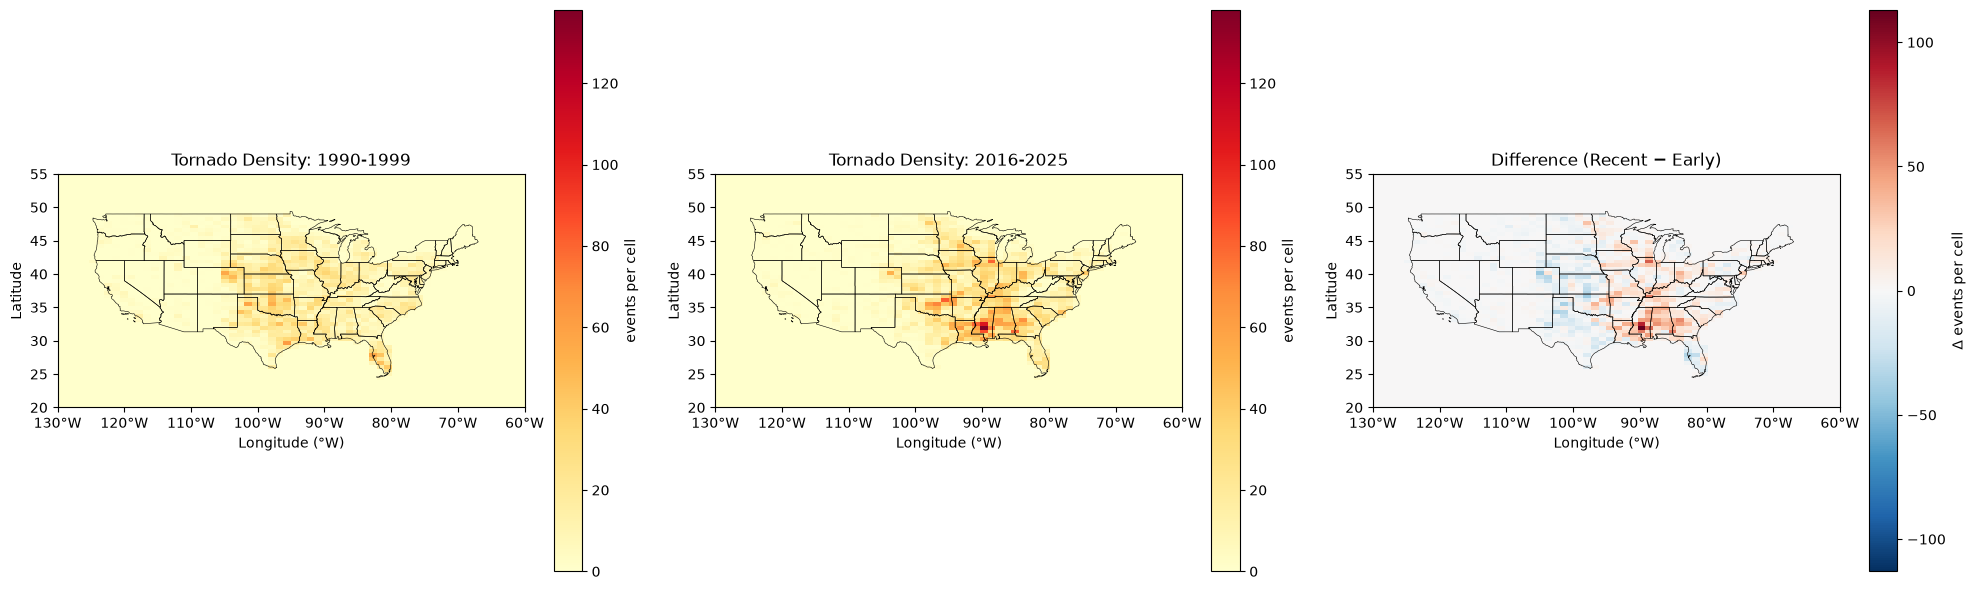

In [12]:
EARLY_START, EARLY_END = 1990, 1999
RECENT_END = df_model["year"].max()
RECENT_START = RECENT_END - 9

df_early  = df_model[(df_model["year"] >= EARLY_START) & (df_model["year"] <= EARLY_END)]
df_recent = df_model[(df_model["year"] >= RECENT_START) & (df_model["year"] <= RECENT_END)]

print(f"Early period  {EARLY_START}-{EARLY_END} : {len(df_early):,} events")
print(f"Recent period {RECENT_START}-{RECENT_END} : {len(df_recent):,} events")

# State outlines for spatial reference (dissolve counties -> states)
counties = gpd.read_file("../data/raw/cb_2020_us_county_20m/cb_2020_us_county_20m.shp")
states = counties.dissolve(by="STATEFP").to_crs("EPSG:4326")
states = states.cx[-130:-60, 20:55]  # drop AK/HI/PR etc., keep CONUS

# Common 2D histogram bins so early/recent grids align exactly -> valid difference map
lon_bins = np.linspace(-130, -60, 61)
lat_bins = np.linspace(20, 55, 61)

hist_early,  _, _ = np.histogram2d(df_early["BEGIN_LON"],  df_early["BEGIN_LAT"],  bins=[lon_bins, lat_bins])
hist_recent, _, _ = np.histogram2d(df_recent["BEGIN_LON"], df_recent["BEGIN_LAT"], bins=[lon_bins, lat_bins])

vmax = max(hist_early.max(), hist_recent.max())

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, hist, title in zip(
    axes[:2], [hist_early, hist_recent],
    [f"{EARLY_START}-{EARLY_END}", f"{RECENT_START}-{RECENT_END}"],
):
    pcm = ax.pcolormesh(lon_bins, lat_bins, hist.T, cmap="YlOrRd", vmin=0, vmax=vmax)
    states.boundary.plot(ax=ax, color="black", linewidth=0.4)
    ax.set_title(f"Tornado Density: {title}")
    ax.set_xlabel("Longitude (°W)")
    ax.xaxis.set_major_formatter(lon_west_formatter)
    ax.set_ylabel("Latitude")
    ax.set_aspect("equal")
    fig.colorbar(pcm, ax=ax, label="events per cell")

diff = hist_recent - hist_early
diff_max = np.abs(diff).max()
pcm_diff = axes[2].pcolormesh(lon_bins, lat_bins, diff.T, cmap="RdBu_r", vmin=-diff_max, vmax=diff_max)
states.boundary.plot(ax=axes[2], color="black", linewidth=0.4)
axes[2].set_title("Difference (Recent − Early)")
axes[2].set_xlabel("Longitude (°W)")
axes[2].xaxis.set_major_formatter(lon_west_formatter)
axes[2].set_ylabel("Latitude")
axes[2].set_aspect("equal")
fig.colorbar(pcm_diff, ax=axes[2], label="Δ events per cell")

plt.tight_layout()
plt.show()


## Eastward Drift Forecast: Quantile Regression

A per-grid-cell spatiotemporal density model (Poisson regression with a
year-drift term) was tested against a spatial-only baseline, validated via
both a single holdout and rolling-origin cross-validation — it showed no
reproducible predictive improvement. 36 years of data isn't enough to
resolve the eastward drift at grid-cell resolution; the single robust trend
in longitude remains the best-supported finding in this data.

To turn that trend into a usable forecast with an uncertainty band, fit
`sklearn.linear_model.QuantileRegressor` (quantile 0.16, 0.50, 0.84)
directly on individual events (`year -> BEGIN_LON`), rather than
pre-aggregating to yearly medians first. This is the same median-regression
idea as Theil-Sen (robust to outliers) but fit on all ~46K events instead
of 36 yearly points, and it extrapolates to any future year natively via
`.predict()`.


In [13]:
FORECAST_YEAR = 2030
REF_YEAR = df_model["year"].max()  # 2025; center year for numerical stability

X_year = (df_model["year"].values - REF_YEAR).reshape(-1, 1)
y_lon  = df_model["BEGIN_LON"].values

quantiles = [0.16, 0.50, 0.84]
qr_models = {}
for q in quantiles:
    qr = QuantileRegressor(quantile=q, alpha=0.0, solver="highs")
    qr.fit(X_year, y_lon)
    qr_models[q] = qr

km_per_deg_lon = 111.0 * np.cos(np.deg2rad(df_model["BEGIN_LAT"].mean()))

print("Quantile regression slopes (fit on all individual events):")
for q in quantiles:
    slope = qr_models[q].coef_[0]
    print(f"  q={q:.2f} : {slope:+.4f}°/yr  ({slope*10:+.2f}°/decade, {slope*10*km_per_deg_lon:+.1f} km/decade)")

qr_median_slope = qr_models[0.50].coef_[0]
print(f"\nMedian regression slope (all events)   : {qr_median_slope:+.4f}°/yr "
      f"-> {qr_median_slope*10*km_per_deg_lon:+.1f} km/decade")
print(f"Theil-Sen slope (yearly medians)        : {lon_slope:+.4f}°/yr "
      f"-> {lon_slope*10*km_per_deg_lon:+.1f} km/decade")

# Forecast: last observed year vs FORECAST_YEAR
X_last     = np.array([[df_model["year"].max() - REF_YEAR]])
X_forecast = np.array([[FORECAST_YEAR - REF_YEAR]])

last_pred     = {q: qr_models[q].predict(X_last)[0]     for q in quantiles}
forecast_pred = {q: qr_models[q].predict(X_forecast)[0] for q in quantiles}

print(f"\nFitted longitude for {df_model['year'].max()} (last observed year):")
for q in quantiles:
    print(f"  q={q:.2f} : {last_pred[q]:+.2f}°")

print(f"\nForecast longitude for {FORECAST_YEAR}:")
for q in quantiles:
    print(f"  q={q:.2f} : {forecast_pred[q]:+.2f}°")

shift_deg = forecast_pred[0.50] - last_pred[0.50]
print(f"\nProjected median eastward shift {df_model['year'].max()}->{FORECAST_YEAR}: "
      f"{shift_deg:+.2f}°  ({shift_deg*km_per_deg_lon:+.1f} km)")


Quantile regression slopes (fit on all individual events):
  q=0.16 : +0.1569°/yr  (+1.57°/decade, +138.8 km/decade)
  q=0.50 : +0.1665°/yr  (+1.66°/decade, +147.3 km/decade)
  q=0.84 : +0.0025°/yr  (+0.03°/decade, +2.2 km/decade)

Median regression slope (all events)   : +0.1665°/yr -> +147.3 km/decade
Theil-Sen slope (yearly medians)        : +0.1584°/yr -> +140.2 km/decade

Fitted longitude for 2025 (last observed year):
  q=0.16 : -96.87°
  q=0.50 : -89.54°
  q=0.84 : -83.66°

Forecast longitude for 2030:
  q=0.16 : -96.09°
  q=0.50 : -88.71°
  q=0.84 : -83.65°

Projected median eastward shift 2025->2030: +0.83°  (+73.7 km)


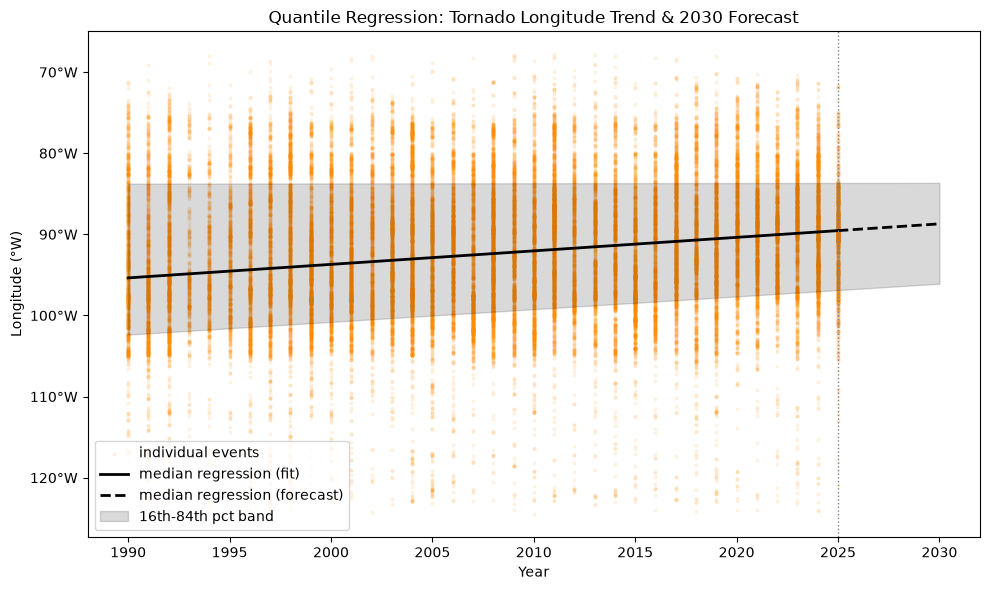

In [14]:
years_plot = np.arange(df_model["year"].min(), FORECAST_YEAR + 1)
X_plot = (years_plot - REF_YEAR).reshape(-1, 1)

pred_lo  = qr_models[0.16].predict(X_plot)
pred_med = qr_models[0.50].predict(X_plot)
pred_hi  = qr_models[0.84].predict(X_plot)

obs_mask = years_plot <= df_model["year"].max()
fc_mask  = years_plot >= df_model["year"].max()  # overlap at boundary so the lines connect

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df_model["year"], df_model["BEGIN_LON"], s=4, alpha=0.08, color="darkorange", label="individual events")

ax.plot(years_plot[obs_mask], pred_med[obs_mask], color="black", lw=2, label="median regression (fit)")
ax.plot(years_plot[fc_mask], pred_med[fc_mask], color="black", lw=2, ls="--", label="median regression (forecast)")
ax.fill_between(years_plot, pred_lo, pred_hi, color="black", alpha=0.15, label="16th-84th pct band")

ax.axvline(df_model["year"].max(), color="gray", ls=":", lw=1)
ax.set_xlabel("Year")
ax.set_ylabel("Longitude (°W)")
ax.yaxis.set_major_formatter(lon_west_formatter)
ax.set_title(f"Quantile Regression: Tornado Longitude Trend & {FORECAST_YEAR} Forecast")
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()
